# LIV Golf — Skill Balance vs. Depth

Investigates whether team success comes from having one dominant star (depth)
or a balanced roster (no weak links), and which SG skill components drive wins
most in LIV's format where all 4 player scores count every event.

**Outputs:**
- `team_skill_profiles.csv` — per team per season: SG mean/std/min/max + balance metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm

DATA_DIR    = Path('../../02_player_dashboard/data')
TRACK_DIR   = Path('../01_performance_tracking')
VAL_CSV     = Path('../../03_player_valuation/liv_player_valuation.csv')
OUT_DIR     = Path('.')

TEAM_COLORS = {
    'Crushers GC':          '#e74c3c',
    'Legion XIII':          '#8e44ad',
    'RangeGoats GC':        '#27ae60',
    'Torque GC':            '#f39c12',
    'HyFlyers GC':          '#2980b9',
    'Ripper GC':            '#16a085',
    'Cleeks Golf Club':     '#2c3e50',
    'Smash GC':             '#c0392b',
    'Majesticks Golf Club': '#7f8c8d',
    'Fireballs GC':         '#e67e22',
    'Southern Guards GC':   '#1abc9c',
    'Korean Golf Club':     '#3498db',
    '4Aces GC':             '#f1c40f',
    'Wild Card':            '#bdc3c7',
}

SHORT_NAMES = {
    'Crushers GC':          'Crushers',
    'Legion XIII':          'Legion XIII',
    'RangeGoats GC':        'RangeGoats',
    'Torque GC':            'Torque',
    'HyFlyers GC':          'HyFlyers',
    'Ripper GC':            'Ripper',
    'Cleeks Golf Club':     'Cleeks',
    'Smash GC':             'Smash',
    'Majesticks Golf Club': 'Majesticks',
    'Fireballs GC':         'Fireballs',
    'Southern Guards GC':   'Southern Guards',
    'Korean Golf Club':     'Korean GC',
    '4Aces GC':             '4Aces',
    'Wild Card':            'Wild Card',
}

SG_COMPONENTS = ['est_sg_total', 'est_sg_ott', 'est_sg_app', 'est_sg_atg', 'est_sg_putt']
SG_LABELS     = ['Total', 'Off Tee', 'Approach', 'Around Green', 'Putting']

plt.rcParams.update({
    'figure.facecolor': '#0e0e1a',
    'axes.facecolor':   '#0e0e1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
print('Setup complete.')

Setup complete.


## Cell 2 — Load & build team skill profiles

In [ ]:
val = pd.read_csv(VAL_CSV)
ss  = pd.read_csv(TRACK_DIR / 'team_season_summary.csv')
te  = pd.read_csv(TRACK_DIR / 'team_event_results.csv')

# ── Build per-team-season skill profiles from player valuation data ────────────
def team_profile(grp):
    row = {}
    for col in SG_COMPONENTS:
        vals = grp[col].dropna()
        if vals.empty:
            row[f'{col}_mean'] = np.nan
            row[f'{col}_std']  = np.nan
            row[f'{col}_min']  = np.nan
            row[f'{col}_max']  = np.nan
        else:
            row[f'{col}_mean'] = vals.mean()
            row[f'{col}_std']  = vals.std(ddof=0)   # population std (small N)
            row[f'{col}_min']  = vals.min()
            row[f'{col}_max']  = vals.max()
    # Star index: best player's SG vs team mean (higher = more star-heavy)
    mean = row['est_sg_total_mean']
    mx   = row['est_sg_total_max']
    row['star_index'] = (mx - mean) if pd.notna(mean) and pd.notna(mx) else np.nan
    row['roster_size'] = len(grp)
    return pd.Series(row)

profiles = (
    val[val['team'].notna()]
    .groupby(['team', 'season'])
    .apply(team_profile, include_groups=False)
    .reset_index()
    .rename(columns={'season': 'year'})
)

# ── Join onto season summary ───────────────────────────────────────────────────
team_skill = ss.merge(profiles, on=['team', 'year'], how='inner')

print(f'Team-season profiles: {len(team_skill)}')
print(f'Seasons: {sorted(team_skill["year"].unique())}')
print(f'Teams:   {sorted(team_skill["team"].unique())}')
team_skill[['team','year','est_sg_total_mean','est_sg_total_std',
            'est_sg_total_min','est_sg_total_max','star_index','win_rate']].head(8)

## Cell 3 — Balance vs depth scatter (SG spread vs win rate)

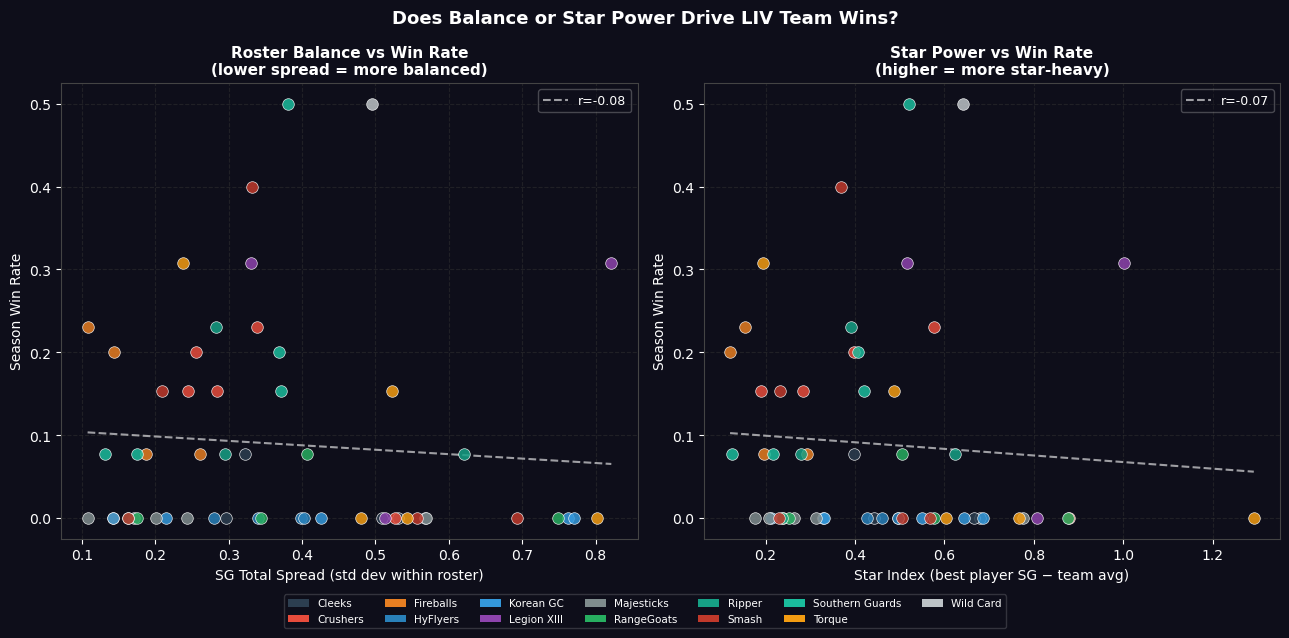

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (xcol, xlabel, title) in zip(axes, [
    ('est_sg_total_std',  'SG Total Spread (std dev within roster)',
     'Roster Balance vs Win Rate\n(lower spread = more balanced)'),
    ('star_index',        'Star Index (best player SG − team avg)',
     'Star Power vs Win Rate\n(higher = more star-heavy)'),
]):
    for _, row in team_skill.iterrows():
        color = TEAM_COLORS.get(row['team'], '#888')
        ax.scatter(row[xcol], row['win_rate'], color=color, s=70,
                   alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3)

    # Trend line
    valid = team_skill[[xcol, 'win_rate']].dropna()
    m, b = np.polyfit(valid[xcol], valid['win_rate'], 1)
    xs = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
    ax.plot(xs, m*xs + b, color='white', linewidth=1.5, linestyle='--', alpha=0.6, label=f'r={valid[[xcol,"win_rate"]].corr().iloc[0,1]:.2f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Season Win Rate')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(True)

# Shared legend for teams
from matplotlib.patches import Patch
handles = [Patch(facecolor=TEAM_COLORS.get(t, '#888'), label=SHORT_NAMES.get(t, t))
           for t in sorted(team_skill['team'].unique())]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=7.5,
           framealpha=0.2, bbox_to_anchor=(0.5, -0.06))

fig.suptitle('Does Balance or Star Power Drive LIV Team Wins?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'balance_vs_depth_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 4 — Weakest link vs ceiling analysis

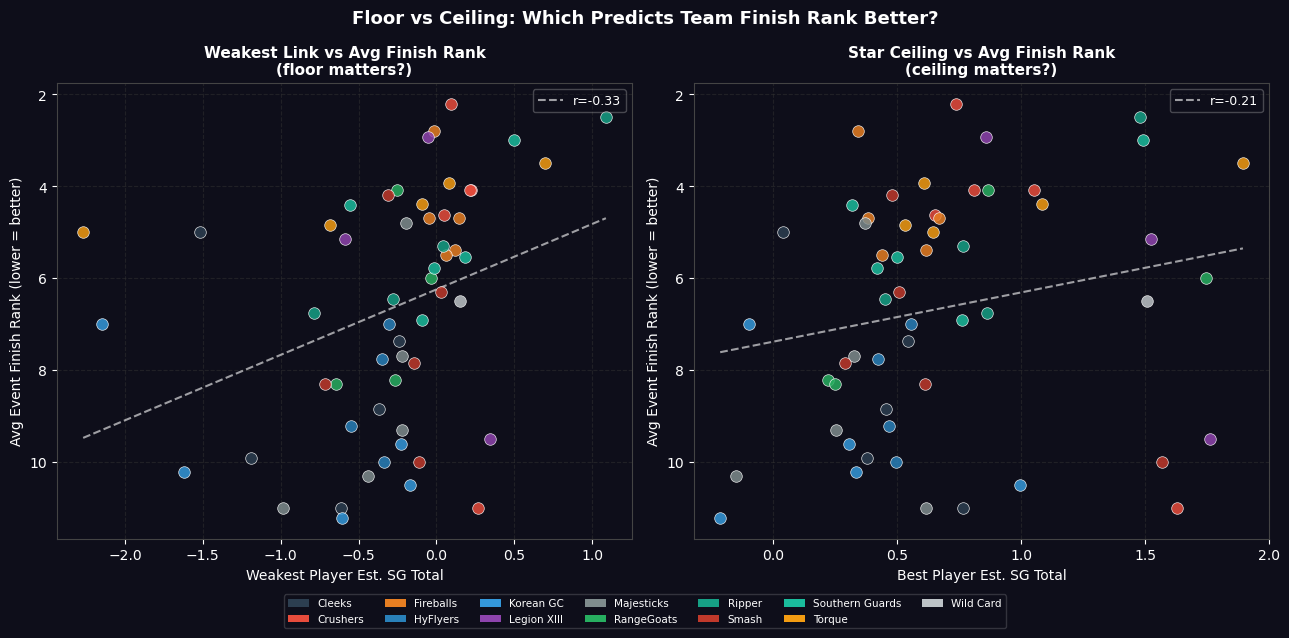

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (xcol, xlabel, title) in zip(axes, [
    ('est_sg_total_min', 'Weakest Player Est. SG Total',
     'Weakest Link vs Avg Finish Rank\n(floor matters?)'),
    ('est_sg_total_max', 'Best Player Est. SG Total',
     'Star Ceiling vs Avg Finish Rank\n(ceiling matters?)'),
]):
    for _, row in team_skill.iterrows():
        color = TEAM_COLORS.get(row['team'], '#888')
        ax.scatter(row[xcol], row['avg_rank'], color=color, s=70,
                   alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3)

    valid = team_skill[[xcol, 'avg_rank']].dropna()
    m, b  = np.polyfit(valid[xcol], valid['avg_rank'], 1)
    xs    = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
    r     = valid[[xcol, 'avg_rank']].corr().iloc[0, 1]
    ax.plot(xs, m*xs + b, color='white', linewidth=1.5, linestyle='--',
            alpha=0.6, label=f'r={r:.2f}')

    ax.invert_yaxis()   # rank 1 = best, at top
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Avg Event Finish Rank (lower = better)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(True)

fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=7.5,
           framealpha=0.2, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Floor vs Ceiling: Which Predicts Team Finish Rank Better?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'floor_vs_ceiling.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — SG component correlation heatmap

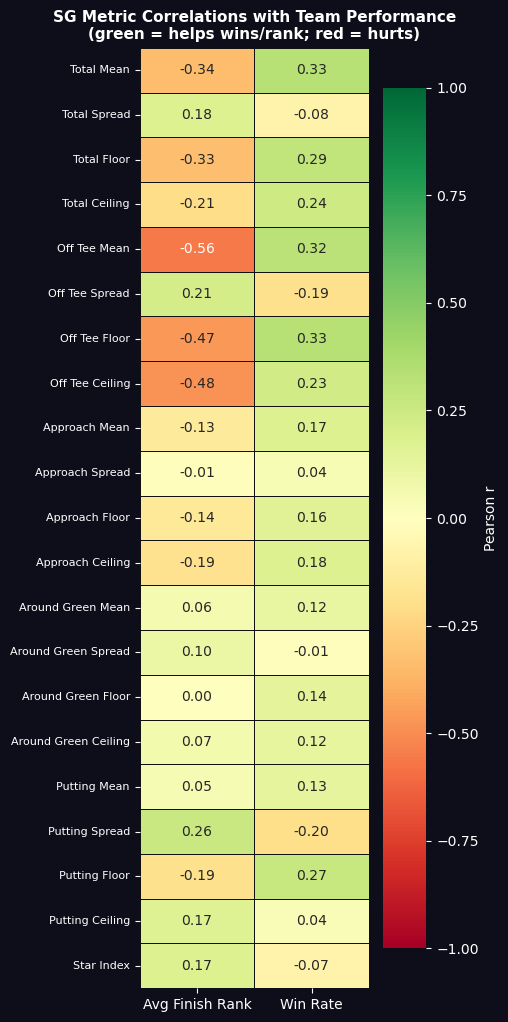

                      Avg Finish Rank  Win Rate
Total Mean                  -0.342672  0.330224
Off Tee Floor               -0.467153  0.328772
Off Tee Mean                -0.558992  0.317059
Total Floor                 -0.332058  0.294914
Putting Floor               -0.194961  0.273122
Total Ceiling               -0.205225  0.244279
Off Tee Ceiling             -0.481616  0.233683
Approach Ceiling            -0.185395  0.175240
Approach Mean               -0.133715  0.172785
Approach Floor              -0.144290  0.160344
Around Green Floor           0.004779  0.138246
Putting Mean                 0.052433  0.128355
Around Green Ceiling         0.066937  0.118682
Around Green Mean            0.062313  0.117152
Approach Spread             -0.010061  0.043510
Putting Ceiling              0.168552  0.037729
Around Green Spread          0.095786 -0.014403
Star Index                   0.174680 -0.073446
Total Spread                 0.179216 -0.079323
Off Tee Spread               0.211870 -0

In [5]:
# Build correlation matrix: each SG metric vs avg_rank and win_rate
metric_cols = []
metric_labels = []
for comp, label in zip(SG_COMPONENTS, SG_LABELS):
    for stat, slabel in [('mean','Mean'), ('std','Spread'), ('min','Floor'), ('max','Ceiling')]:
        col = f'{comp}_{stat}'
        if col in team_skill.columns:
            metric_cols.append(col)
            metric_labels.append(f'{label} {slabel}')
metric_cols.append('star_index')
metric_labels.append('Star Index')

targets = ['avg_rank', 'win_rate']
corr_data = {}
for t in targets:
    corr_data[t] = [
        team_skill[[col, t]].dropna().corr().iloc[0, 1]
        for col in metric_cols
    ]

corr_df = pd.DataFrame(corr_data, index=metric_labels)
corr_df.columns = ['Avg Finish Rank', 'Win Rate']

fig, ax = plt.subplots(figsize=(5, len(metric_labels) * 0.42 + 1.5))
sns.heatmap(
    corr_df,
    ax=ax,
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.4, linecolor='#111',
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title('SG Metric Correlations with Team Performance\n'
             '(green = helps wins/rank; red = hurts)',
             fontsize=11, fontweight='bold')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'sg_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_df.sort_values('Win Rate', ascending=False).to_string())

## Cell 6 — Component importance bar chart

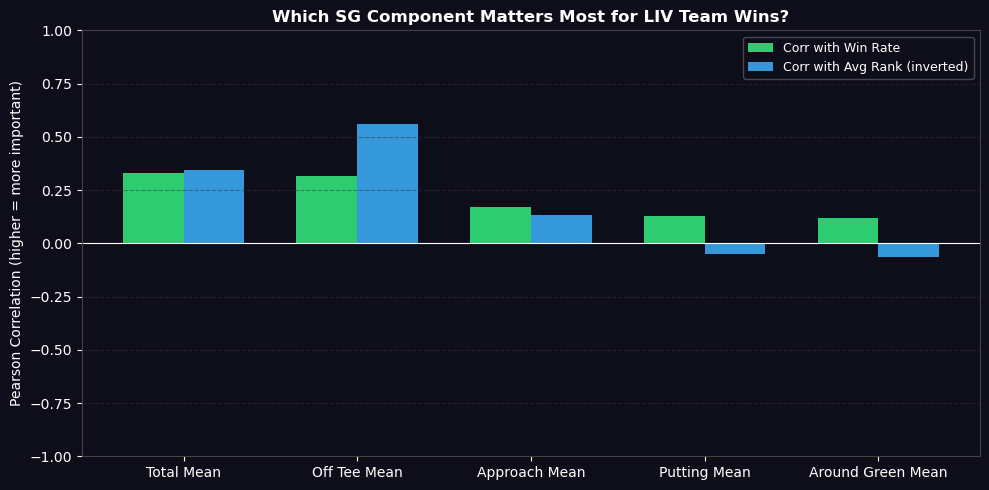

In [6]:
# Focus on team mean SG per component vs win_rate — clearest "what matters" signal
mean_cols   = [f'{c}_mean' for c in SG_COMPONENTS]
mean_labels = [f'{l} Mean' for l in SG_LABELS]

corrs_winrate = [
    team_skill[[col, 'win_rate']].dropna().corr().iloc[0, 1]
    for col in mean_cols
]
corrs_rank = [
    team_skill[[col, 'avg_rank']].dropna().corr().iloc[0, 1]
    for col in mean_cols
]

order = np.argsort(corrs_winrate)[::-1]
labels_sorted  = [mean_labels[i] for i in order]
wr_sorted      = [corrs_winrate[i] for i in order]
rank_sorted    = [corrs_rank[i] for i in order]

x = np.arange(len(labels_sorted))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, wr_sorted,   w, label='Corr with Win Rate',
               color='#2ecc71', edgecolor='none')
bars2 = ax.bar(x + w/2, [-r for r in rank_sorted], w,
               label='Corr with Avg Rank (inverted)',
               color='#3498db', edgecolor='none')

ax.axhline(0, color='white', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_sorted, fontsize=10)
ax.set_ylabel('Pearson Correlation (higher = more important)')
ax.set_title('Which SG Component Matters Most for LIV Team Wins?',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(axis='y')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / 'component_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Star index by win tier

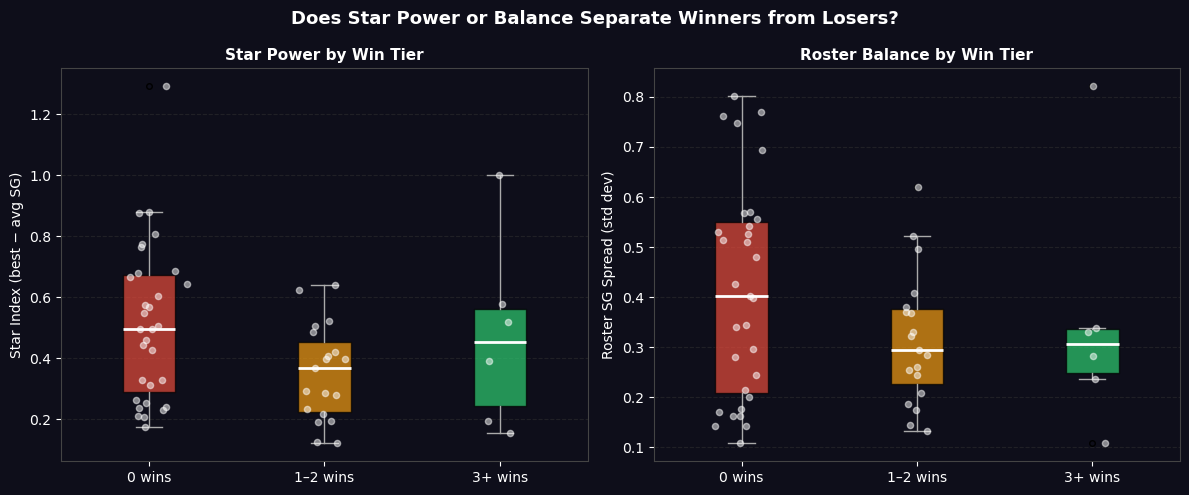

In [7]:
team_skill['win_tier'] = pd.cut(
    team_skill['wins'],
    bins=[-1, 0, 2, 100],
    labels=['0 wins', '1–2 wins', '3+ wins']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, ylabel, title) in zip(axes, [
    ('star_index',        'Star Index (best − avg SG)',
     'Star Power by Win Tier'),
    ('est_sg_total_std',  'Roster SG Spread (std dev)',
     'Roster Balance by Win Tier'),
]):
    tier_order = ['0 wins', '1–2 wins', '3+ wins']
    data_by_tier = [team_skill[team_skill['win_tier'] == t][col].dropna() for t in tier_order]

    bp = ax.boxplot(
        data_by_tier,
        labels=tier_order,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color='#aaa'),
        capprops=dict(color='#aaa'),
        flierprops=dict(marker='o', color='#aaa', markersize=4),
    )
    colors = ['#e74c3c', '#f39c12', '#2ecc71']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Overlay individual points
    for i, (tier, data) in enumerate(zip(tier_order, data_by_tier), start=1):
        jitter = np.random.normal(0, 0.06, size=len(data))
        ax.scatter(i + jitter, data, color='white', s=20, alpha=0.5, zorder=3)

    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y')

fig.suptitle('Does Star Power or Balance Separate Winners from Losers?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'win_tier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Linear regression: predicting avg finish rank

=== OLS: Predicting Avg Event Finish Rank ===
R²       : 0.206
Adj. R²  : 0.160
N        : 56

Predictor                          Coef    p-value  Interpretation
---------------------------------------------------------------------------
Intercept                         5.850     0.0000  *** ↑ rank (worse)
Team Avg SG (quality)            -8.567     0.0154  ** ↓ rank (better)
Roster SG Spread (balance)       11.548     0.0255  ** ↑ rank (worse)
Weakest Player SG (floor)         5.521     0.0579  * ↑ rank (worse)


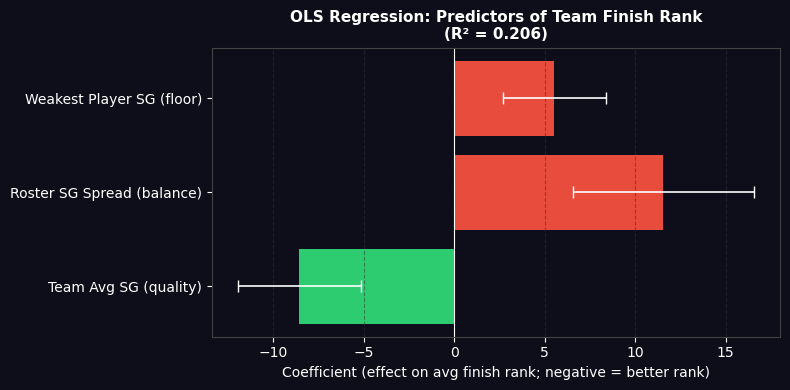

In [8]:
reg_cols = ['est_sg_total_mean', 'est_sg_total_std', 'est_sg_total_min']
reg_labels = ['Team Avg SG (quality)', 'Roster SG Spread (balance)', 'Weakest Player SG (floor)']

reg_data = team_skill[reg_cols + ['avg_rank']].dropna()
X = sm.add_constant(reg_data[reg_cols])
y = reg_data['avg_rank']

model = sm.OLS(y, X).fit()

print('=== OLS: Predicting Avg Event Finish Rank ===')
print(f'R²       : {model.rsquared:.3f}')
print(f'Adj. R²  : {model.rsquared_adj:.3f}')
print(f'N        : {len(reg_data)}')
print()
print(f'{"Predictor":<30} {"Coef":>8} {"p-value":>10}  Interpretation')
print('-' * 75)
for col, label, coef, pval in zip(
    ['const'] + reg_cols,
    ['Intercept'] + reg_labels,
    model.params,
    model.pvalues,
):
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    direction = '↑ rank (worse)' if coef > 0 else '↓ rank (better)'
    print(f'{label:<30} {coef:>8.3f} {pval:>10.4f}  {sig} {direction}')

# Visualize coefficients
coefs  = model.params[reg_cols]
errors = model.bse[reg_cols]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if c < 0 else '#e74c3c' for c in coefs]
ax.barh(reg_labels, coefs, xerr=errors, color=colors, edgecolor='none',
        error_kw=dict(ecolor='white', capsize=4, linewidth=1.2))
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Coefficient (effect on avg finish rank; negative = better rank)')
ax.set_title(f'OLS Regression: Predictors of Team Finish Rank\n(R² = {model.rsquared:.3f})',
             fontsize=11, fontweight='bold')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig(OUT_DIR / 'regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Season summary table (most recent full season)

In [9]:
# Most recent season with >= 10 events
full_seasons = ss.groupby('year')['events'].max()
latest_yr = full_seasons[full_seasons >= 10].index.max()

latest = team_skill[team_skill['year'] == latest_yr].copy()
latest['team_short'] = latest['team'].map(SHORT_NAMES).fillna(latest['team'])

display_cols = {
    'team_short':           'Team',
    'est_sg_total_mean':    'Avg SG',
    'est_sg_total_std':     'SG Spread',
    'est_sg_total_min':     'Floor SG',
    'est_sg_total_max':     'Ceiling SG',
    'star_index':           'Star Index',
    'wins':                 'Wins',
    'win_rate':             'Win Rate',
    'avg_rank':             'Avg Rank',
}
table = latest[list(display_cols)].rename(columns=display_cols)
table = table.sort_values('Win Rate', ascending=False).reset_index(drop=True)
table.index = table.index + 1

print(f'=== {latest_yr} Season — Team Skill Profiles ===')
print(table.to_string(
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else str(x)
))

=== 2025 Season — Team Skill Profiles ===
               Team  Avg SG  SG Spread  Floor SG  Ceiling SG  Star Index  Wins  Win Rate  Avg Rank
1       Legion XIII   0.339      0.330    -0.052       0.856       0.517     4     0.308     2.920
2          Crushers   0.474      0.339     0.216       1.052       0.577     3     0.231     4.080
3         Fireballs   0.227      0.109     0.148       0.381       0.154     3     0.231     4.690
4            Torque   0.044      0.522    -0.680       0.531       0.487     2     0.154     4.850
5            Ripper   0.173      0.295    -0.280       0.452       0.279     1     0.077     6.460
6   Southern Guards   0.203      0.175    -0.014       0.419       0.216     1     0.077     5.770
7            Cleeks  -0.300      0.568    -1.192       0.379       0.679     0     0.000     9.920
8          HyFlyers   0.092      0.280    -0.348       0.420       0.328     0     0.000     7.770
9         Korean GC  -0.427      0.142    -0.608      -0.215       

## Cell 10 — Save outputs

In [10]:
team_skill.to_csv(OUT_DIR / 'team_skill_profiles.csv', index=False)

print(f'Saved team_skill_profiles.csv — {len(team_skill)} rows')
print()
print('=== Key findings ===')

# Report top correlates with win rate
all_corrs = [
    (label, team_skill[[col, 'win_rate']].dropna().corr().iloc[0, 1])
    for col, label in zip(metric_cols, metric_labels)
]
all_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print('Top correlates with Win Rate:')
for label, r in all_corrs[:5]:
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {label:<30} r={r:+.3f}  ({direction})')

Saved team_skill_profiles.csv — 56 rows

=== Key findings ===
Top correlates with Win Rate:
  Total Mean                     r=+0.330  (positive)
  Off Tee Floor                  r=+0.329  (positive)
  Off Tee Mean                   r=+0.317  (positive)
  Total Floor                    r=+0.295  (positive)
  Putting Floor                  r=+0.273  (positive)
